# Feature Scaling 

In [ ]:
# Data ke values ko ek common scale pe lana

# Example:

# Salary = 50000
# Experience = 2

# 👉 ML model confuse ho sakta hai (kyuki scale alag hai)

### Types ->
#### 1. Standardization
#### 2. Normalization

In [ ]:
# 1️⃣ Standardization (Z-score Scaling)
# 👉 Formula:
# Xnew ​= (X−μ​)/𝜎

# 👉 jaha:
# μ = mean
# σ = standard deviation

# 2️⃣ Normalization (Min-Max Scaling)
# 👉 Formula:
# Xnew ​= (​X−Xmin)​/(Xmax​−Xmin)

# Result:
# Values → 0 se 1 ke beech


# ⚡ Difference (Important Table)
# Feature	     Standardization	           Normalization
# Range	         No fixed range	                  0 to 1
# Mean	             0	                          not fixed
# Outliers	     handle better	                  sensitive
# Formula	      (x-mean)/std	                (x-min)/(max-min)

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(r"C:\Users\harsh\Downloads\archive (1)\uk_universities.csv")
df

,University_name,Region,Founded_year,Motto,UK_rank,World_rank,CWUR_score,Minimum_IELTS_score,UG_average_fees_(in_pounds),PG_average_fees_(in_pounds),...,Student_satisfaction,Student_enrollment,Academic_staff,Control_type,Academic_Calender,Campus_setting,Estimated_cost_of_living_per_year_(in_pounds),Latitude,Longitude,Website
0,University of Cambridge,East of England,1209,"From here, light and sacred draughts",1,4,94.1,6.5,21750,23187,...,85.50%,"20,000-24,999","over-5,000",Public,Trimesters,Urban,12000,52.2054,0.1132,www.cam.ac.uk
1,University of Oxford,South East England,1096,The Lord is my light,2,2,93.3,6.5,21770,19888,...,86.50%,"25,000-29,999","over-5,000",Public,Trimesters,Urban,11500,51.7548,-1.2544,www.ox.ac.uk
2,University of St Andrews,Scotland,1413,Ever to excel,3,86,75.8,6.5,17040,15440,...,87.90%,"10,000-14,999","1,000-1,499",Public,Semesters,Suburban,12000,56.3417,-2.7943,www.st-andrews.ac.uk
3,Imperial College London,London,1907,Knowledge is the adornment and safeguard of th...,4,8,86.6,6.5,23500,29900,...,77.90%,"15,000-19,999","4,000-4,499",Public,Continuous,Urban,10700,51.4988,-0.1749,www.ic.ac.uk
4,Loughborough University,East Midlands,1966,"With Truth, Knowledge and Labour",5,404,72.8,5.5,16400,16400,...,85.80%,"15,000-19,999","1,500-1,999",Public,Semesters,Suburban,9398,52.7650,-1.2321,www.lboro.ac.uk/
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126,University of East London,London,1992,Science and fulfillment of vows,127,971,NaN,4.5,10700,11700,...,76.10%,"10,000-14,999",900-999,Public,Semesters,Suburban,10229,51.5076,0.0651,www.uel.ac.uk
127,University of Bedfordshire,East of England,2006,NaN,128,1281,NaN,4.5,9750,9900,...,77.40%,"10,000-14,999",500-599,Public,Semesters,Urban,9415,51.8779,-0.4093,www.beds.ac.uk
128,University of Suffolk,East of England,2007,Honesty and diligence,129,4030,NaN,4.5,9495,9495,...,76.00%,"7,000-7,999",200-299,Public,NaN,NaN,9415,52.0523,1.1629,www.ucs.ac.uk/
129,Wrexham Glyndwr University,Wales,2008,Confidence through Education,130,2397,NaN,4.5,10250,10500,...,74.30%,"5,000-5,999",200-299,Public,NaN,Urban,7771,53.0526,-3.0062,www.glyndwr.ac.uk/


In [4]:
df.head(3)

,University_name,Region,Founded_year,Motto,UK_rank,World_rank,CWUR_score,Minimum_IELTS_score,UG_average_fees_(in_pounds),PG_average_fees_(in_pounds),...,Student_satisfaction,Student_enrollment,Academic_staff,Control_type,Academic_Calender,Campus_setting,Estimated_cost_of_living_per_year_(in_pounds),Latitude,Longitude,Website
0,University of Cambridge,East of England,1209,"From here, light and sacred draughts",1,4,94.1,6.5,21750,23187,...,85.50%,"20,000-24,999","over-5,000",Public,Trimesters,Urban,12000,52.2054,0.1132,www.cam.ac.uk
1,University of Oxford,South East England,1096,The Lord is my light,2,2,93.3,6.5,21770,19888,...,86.50%,"25,000-29,999","over-5,000",Public,Trimesters,Urban,11500,51.7548,-1.2544,www.ox.ac.uk
2,University of St Andrews,Scotland,1413,Ever to excel,3,86,75.8,6.5,17040,15440,...,87.90%,"10,000-14,999","1,000-1,499",Public,Semesters,Suburban,12000,56.3417,-2.7943,www.st-andrews.ac.uk


In [5]:
df.isnull().sum()

University_name                                   0
Region                                            0
Founded_year                                      0
Motto                                            17
UK_rank                                           0
World_rank                                        0
CWUR_score                                       47
Minimum_IELTS_score                               0
UG_average_fees_(in_pounds)                       0
PG_average_fees_(in_pounds)                       0
International_students                            0
Student_satisfaction                              0
Student_enrollment                                0
Academic_staff                                    0
Control_type                                      0
Academic_Calender                                26
Campus_setting                                   18
Estimated_cost_of_living_per_year_(in_pounds)     0
Latitude                                          0
Longitude   

# Standardization

In [6]:
df["CWUR_score"].fillna(df["CWUR_score"].mean(),inplace=True)
# CWUR_score me sari null values ko iske mean se fill krega to is col. m ab ek bhi null value nhi bachegi

C:\Users\harsh\AppData\Local\Temp\ipykernel_16680\101401591.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["CWUR_score"].fillna(df["CWUR_score"].mean(),inplace=True)


In [7]:
df.isnull().sum()

University_name                                   0
Region                                            0
Founded_year                                      0
Motto                                            17
UK_rank                                           0
World_rank                                        0
CWUR_score                                        0
Minimum_IELTS_score                               0
UG_average_fees_(in_pounds)                       0
PG_average_fees_(in_pounds)                       0
International_students                            0
Student_satisfaction                              0
Student_enrollment                                0
Academic_staff                                    0
Control_type                                      0
Academic_Calender                                26
Campus_setting                                   18
Estimated_cost_of_living_per_year_(in_pounds)     0
Latitude                                          0
Longitude   

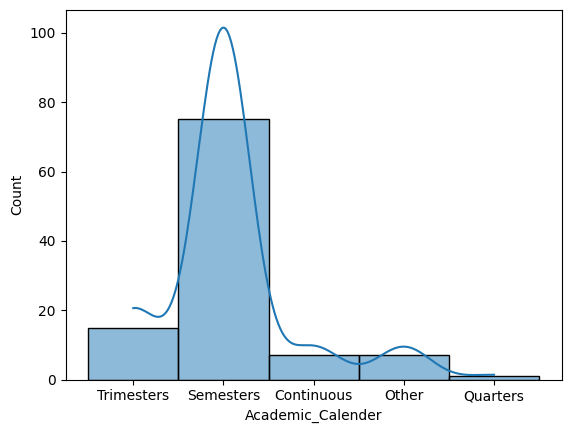

In [8]:
# histplot use kar rahe hain data ka distribution dekhne ke liye
# yaha Academic_Calender column ka histogram banega (bars)

# kde=True ka matlab:
# ek smooth curve (KDE = Kernel Density Estimation) bhi draw hoga
# jo data ka distribution smooth form me dikhata hai

# ⚠️ Note:
# histplot normally numerical data ke liye hota hai
# agar Academic_Calender categorical (text) hai,
# to ye graph meaningful nahi hoga (sirf labels ko bins bana dega)

sns.histplot(df["Academic_Calender"], kde=True)

# graph ko display karne ke liye
plt.show()


# ❌ distplot kyu use nahi kiya?
# distplot seaborn ka old (deprecated) function hai
# newer versions me ye remove ho raha hai
# isliye uski jagah histplot ya displot use karte hain

# 👉 isliye:
# sns.distplot(...) ❌ avoid
# sns.histplot(...) ✅ recommended

In [9]:
df.describe()

,Founded_year,UK_rank,World_rank,CWUR_score,Minimum_IELTS_score,UG_average_fees_(in_pounds),PG_average_fees_(in_pounds),Estimated_cost_of_living_per_year_(in_pounds),Latitude,Longitude
count,131.000000,131.000000,131.00000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000
mean,1925.221374,65.900763,1097.59542,73.960714,4.946565,12537.450382,13099.763359,8644.732824,52.749708,-1.673287
std,139.040187,37.922158,1145.00106,5.075068,0.617850,2555.318861,3106.398149,1579.049538,1.638257,1.503049
min,1096.000000,1.000000,2.00000,65.900000,4.000000,8350.000000,6000.000000,5500.000000,50.171300,-6.675200
25%,1896.000000,33.500000,196.00000,71.000000,4.500000,10758.000000,11250.000000,7710.500000,51.499700,-2.748000
50%,1966.000000,65.000000,691.00000,73.960714,4.500000,12000.000000,12500.000000,8217.000000,52.407400,-1.551600
75%,1992.000000,98.000000,1569.00000,74.550000,5.500000,13825.000000,14182.500000,9457.500000,53.608500,-0.388150
max,2013.000000,131.000000,5253.00000,94.100000,6.500000,23500.000000,29900.000000,15000.000000,57.164800,1.296700


In [10]:
from sklearn.preprocessing  import StandardScaler

In [11]:
ss = StandardScaler()
ss.fit(df[["Minimum_IELTS_score"]])

,copy,True
,with_mean,True
,with_std,True


In [12]:
ss.transform(df[["Minimum_IELTS_score"]])

array([[ 2.52391271],
       [ 2.52391271],
       [ 2.52391271],
       [ 2.52391271],
       [ 0.89918266],
       [ 2.52391271],
       [ 0.89918266],
       [ 0.89918266],
       [ 2.52391271],
       [ 0.89918266],
       [ 0.89918266],
       [ 0.89918266],
       [ 0.89918266],
       [ 0.89918266],
       [ 0.89918266],
       [ 0.89918266],
       [-0.72554739],
       [ 0.89918266],
       [ 0.89918266],
       [ 0.89918266],
       [ 0.89918266],
       [ 0.89918266],
       [ 0.89918266],
       [ 0.89918266],
       [ 0.89918266],
       [ 0.89918266],
       [ 0.89918266],
       [ 0.89918266],
       [ 0.89918266],
       [ 0.89918266],
       [-0.72554739],
       [ 0.89918266],
       [ 0.89918266],
       [ 0.89918266],
       [ 0.89918266],
       [ 0.89918266],
       [ 0.89918266],
       [ 0.89918266],
       [ 0.89918266],
       [-0.72554739],
       [-0.72554739],
       [-0.72554739],
       [-0.72554739],
       [ 0.89918266],
       [-0.72554739],
       [ 0

In [13]:
df["Minimum_IELTS_score_ss"] = pd.DataFrame(ss.transform(df[["Minimum_IELTS_score"]]),columns=["Minimum_IELTS_score_ss"])

In [14]:
df.head(3)

,University_name,Region,Founded_year,Motto,UK_rank,World_rank,CWUR_score,Minimum_IELTS_score,UG_average_fees_(in_pounds),PG_average_fees_(in_pounds),...,Student_enrollment,Academic_staff,Control_type,Academic_Calender,Campus_setting,Estimated_cost_of_living_per_year_(in_pounds),Latitude,Longitude,Website,Minimum_IELTS_score_ss
0,University of Cambridge,East of England,1209,"From here, light and sacred draughts",1,4,94.1,6.5,21750,23187,...,"20,000-24,999","over-5,000",Public,Trimesters,Urban,12000,52.2054,0.1132,www.cam.ac.uk,2.523913
1,University of Oxford,South East England,1096,The Lord is my light,2,2,93.3,6.5,21770,19888,...,"25,000-29,999","over-5,000",Public,Trimesters,Urban,11500,51.7548,-1.2544,www.ox.ac.uk,2.523913
2,University of St Andrews,Scotland,1413,Ever to excel,3,86,75.8,6.5,17040,15440,...,"10,000-14,999","1,000-1,499",Public,Semesters,Suburban,12000,56.3417,-2.7943,www.st-andrews.ac.uk,2.523913


In [15]:
df.describe()

,Founded_year,UK_rank,World_rank,CWUR_score,Minimum_IELTS_score,UG_average_fees_(in_pounds),PG_average_fees_(in_pounds),Estimated_cost_of_living_per_year_(in_pounds),Latitude,Longitude,Minimum_IELTS_score_ss
count,131.000000,131.000000,131.00000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,1.310000e+02
mean,1925.221374,65.900763,1097.59542,73.960714,4.946565,12537.450382,13099.763359,8644.732824,52.749708,-1.673287,-3.796793e-16
std,139.040187,37.922158,1145.00106,5.075068,0.617850,2555.318861,3106.398149,1579.049538,1.638257,1.503049,1.003839e+00
min,1096.000000,1.000000,2.00000,65.900000,4.000000,8350.000000,6000.000000,5500.000000,50.171300,-6.675200,-1.537912e+00
25%,1896.000000,33.500000,196.00000,71.000000,4.500000,10758.000000,11250.000000,7710.500000,51.499700,-2.748000,-7.255474e-01
50%,1966.000000,65.000000,691.00000,73.960714,4.500000,12000.000000,12500.000000,8217.000000,52.407400,-1.551600,-7.255474e-01
75%,1992.000000,98.000000,1569.00000,74.550000,5.500000,13825.000000,14182.500000,9457.500000,53.608500,-0.388150,8.991827e-01
max,2013.000000,131.000000,5253.00000,94.100000,6.500000,23500.000000,29900.000000,15000.000000,57.164800,1.296700,2.523913e+00


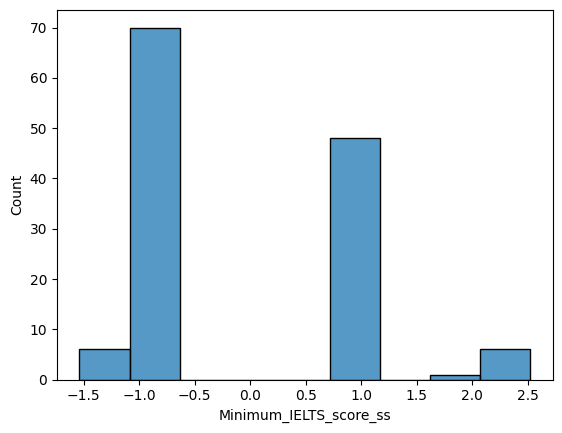

In [16]:
sns.histplot(df["Minimum_IELTS_score_ss"])  # ss -> StandardScalar
plt.show()

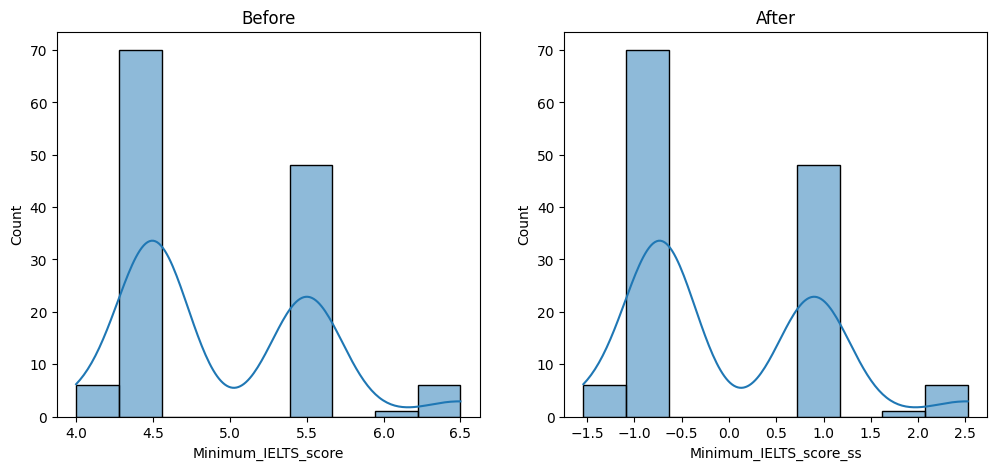

In [17]:
plt.figure(figsize=(12, 5))
# Before (original data)
plt.subplot(1, 2, 1)
plt.title("Before")
sns.histplot(df["Minimum_IELTS_score"], kde=True)

# After (scaled data)
plt.subplot(1, 2, 2)
plt.title("After")
sns.histplot(df["Minimum_IELTS_score_ss"], kde=True)

plt.show()

In [18]:
df.describe()

,Founded_year,UK_rank,World_rank,CWUR_score,Minimum_IELTS_score,UG_average_fees_(in_pounds),PG_average_fees_(in_pounds),Estimated_cost_of_living_per_year_(in_pounds),Latitude,Longitude,Minimum_IELTS_score_ss
count,131.000000,131.000000,131.00000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,1.310000e+02
mean,1925.221374,65.900763,1097.59542,73.960714,4.946565,12537.450382,13099.763359,8644.732824,52.749708,-1.673287,-3.796793e-16
std,139.040187,37.922158,1145.00106,5.075068,0.617850,2555.318861,3106.398149,1579.049538,1.638257,1.503049,1.003839e+00
min,1096.000000,1.000000,2.00000,65.900000,4.000000,8350.000000,6000.000000,5500.000000,50.171300,-6.675200,-1.537912e+00
25%,1896.000000,33.500000,196.00000,71.000000,4.500000,10758.000000,11250.000000,7710.500000,51.499700,-2.748000,-7.255474e-01
50%,1966.000000,65.000000,691.00000,73.960714,4.500000,12000.000000,12500.000000,8217.000000,52.407400,-1.551600,-7.255474e-01
75%,1992.000000,98.000000,1569.00000,74.550000,5.500000,13825.000000,14182.500000,9457.500000,53.608500,-0.388150,8.991827e-01
max,2013.000000,131.000000,5253.00000,94.100000,6.500000,23500.000000,29900.000000,15000.000000,57.164800,1.296700,2.523913e+00


# Normalization

In [19]:
df.isnull().sum()

University_name                                   0
Region                                            0
Founded_year                                      0
Motto                                            17
UK_rank                                           0
World_rank                                        0
CWUR_score                                        0
Minimum_IELTS_score                               0
UG_average_fees_(in_pounds)                       0
PG_average_fees_(in_pounds)                       0
International_students                            0
Student_satisfaction                              0
Student_enrollment                                0
Academic_staff                                    0
Control_type                                      0
Academic_Calender                                26
Campus_setting                                   18
Estimated_cost_of_living_per_year_(in_pounds)     0
Latitude                                          0
Longitude   

In [20]:
df.describe()

,Founded_year,UK_rank,World_rank,CWUR_score,Minimum_IELTS_score,UG_average_fees_(in_pounds),PG_average_fees_(in_pounds),Estimated_cost_of_living_per_year_(in_pounds),Latitude,Longitude,Minimum_IELTS_score_ss
count,131.000000,131.000000,131.00000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,1.310000e+02
mean,1925.221374,65.900763,1097.59542,73.960714,4.946565,12537.450382,13099.763359,8644.732824,52.749708,-1.673287,-3.796793e-16
std,139.040187,37.922158,1145.00106,5.075068,0.617850,2555.318861,3106.398149,1579.049538,1.638257,1.503049,1.003839e+00
min,1096.000000,1.000000,2.00000,65.900000,4.000000,8350.000000,6000.000000,5500.000000,50.171300,-6.675200,-1.537912e+00
25%,1896.000000,33.500000,196.00000,71.000000,4.500000,10758.000000,11250.000000,7710.500000,51.499700,-2.748000,-7.255474e-01
50%,1966.000000,65.000000,691.00000,73.960714,4.500000,12000.000000,12500.000000,8217.000000,52.407400,-1.551600,-7.255474e-01
75%,1992.000000,98.000000,1569.00000,74.550000,5.500000,13825.000000,14182.500000,9457.500000,53.608500,-0.388150,8.991827e-01
max,2013.000000,131.000000,5253.00000,94.100000,6.500000,23500.000000,29900.000000,15000.000000,57.164800,1.296700,2.523913e+00


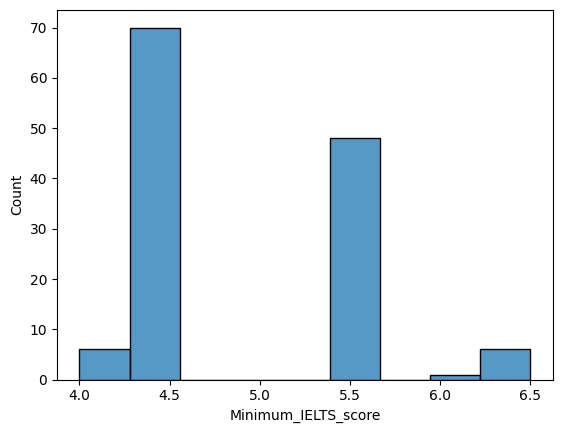

In [21]:
sns.histplot(df["Minimum_IELTS_score"])
plt.show()

In [22]:
from sklearn.preprocessing import MinMaxScaler

In [23]:
ms = MinMaxScaler()
ms.fit(df[["Minimum_IELTS_score"]])

# 👉 sklearn ko 2D data (table format) chahiye hota hai  
# 👉 isliye double bracket use karte hain

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [24]:
ms.transform(df[["Minimum_IELTS_score"]])

array([[1. ],
       [1. ],
       [1. ],
       [1. ],
       [0.6],
       [1. ],
       [0.6],
       [0.6],
       [1. ],
       [0.6],
       [0.6],
       [0.6],
       [0.6],
       [0.6],
       [0.6],
       [0.6],
       [0.2],
       [0.6],
       [0.6],
       [0.6],
       [0.6],
       [0.6],
       [0.6],
       [0.6],
       [0.6],
       [0.6],
       [0.6],
       [0.6],
       [0.6],
       [0.6],
       [0.2],
       [0.6],
       [0.6],
       [0.6],
       [0.6],
       [0.6],
       [0.6],
       [0.6],
       [0.6],
       [0.2],
       [0.2],
       [0.2],
       [0.2],
       [0.6],
       [0.2],
       [0.6],
       [0.6],
       [0.6],
       [0.6],
       [0.2],
       [0.2],
       [0.2],
       [0.2],
       [0.6],
       [0.2],
       [0.6],
       [0.2],
       [0.2],
       [0.2],
       [0.2],
       [0.2],
       [0.2],
       [0.2],
       [0.2],
       [0.2],
       [0.2],
       [0.6],
       [0.6],
       [0.2],
       [0.6],
       [0.2],
      

In [25]:
df["Minimum_IELTS_score"] = ms.transform(df[["Minimum_IELTS_score"]])

In [26]:
df.head(3)

,University_name,Region,Founded_year,Motto,UK_rank,World_rank,CWUR_score,Minimum_IELTS_score,UG_average_fees_(in_pounds),PG_average_fees_(in_pounds),...,Student_enrollment,Academic_staff,Control_type,Academic_Calender,Campus_setting,Estimated_cost_of_living_per_year_(in_pounds),Latitude,Longitude,Website,Minimum_IELTS_score_ss
0,University of Cambridge,East of England,1209,"From here, light and sacred draughts",1,4,94.1,1.0,21750,23187,...,"20,000-24,999","over-5,000",Public,Trimesters,Urban,12000,52.2054,0.1132,www.cam.ac.uk,2.523913
1,University of Oxford,South East England,1096,The Lord is my light,2,2,93.3,1.0,21770,19888,...,"25,000-29,999","over-5,000",Public,Trimesters,Urban,11500,51.7548,-1.2544,www.ox.ac.uk,2.523913
2,University of St Andrews,Scotland,1413,Ever to excel,3,86,75.8,1.0,17040,15440,...,"10,000-14,999","1,000-1,499",Public,Semesters,Suburban,12000,56.3417,-2.7943,www.st-andrews.ac.uk,2.523913


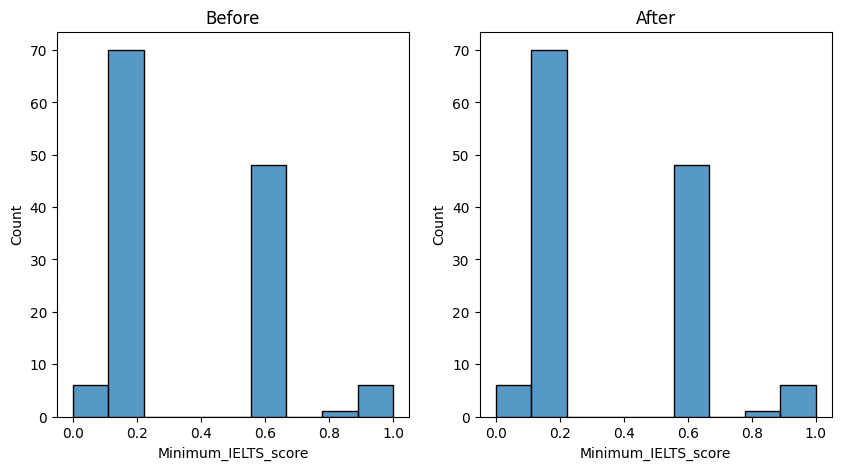

In [27]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Before")
sns.histplot(df["Minimum_IELTS_score"])

plt.subplot(1,2,2)
plt.title("After")
sns.histplot(df["Minimum_IELTS_score"])

plt.show()